In [1]:
import copy
import os
import random

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
# ============================================================
# 1. Reproducibility and device configuration
# ============================================================
def seed_everything(seed=42):
    """
    Set random seeds for reproducible model training.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True)
    except Exception as error:
        print(
            "Warning: deterministic algorithms "
            f"were not fully enabled: {error}"
        )


seed_everything(42)

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: cpu


In [3]:
# ============================================================
# 2. Define the multilayer perceptron model
# ============================================================
class MLPRegressor(nn.Module):
    """
    Multilayer perceptron for overpotential regression.
    """

    def __init__(
        self,
        input_dim,
        hidden_dims=None,
        dropout=0.1
    ):
        super().__init__()

        if hidden_dims is None:
            hidden_dims = [256, 128, 64]

        feature_layers = []
        dimensions = [input_dim] + hidden_dims

        for i in range(len(hidden_dims)):
            feature_layers.append(
                nn.Linear(
                    dimensions[i],
                    dimensions[i + 1]
                )
            )

            feature_layers.append(
                nn.BatchNorm1d(
                    dimensions[i + 1]
                )
            )

            feature_layers.append(
                nn.ReLU()
            )

            feature_layers.append(
                nn.Dropout(dropout)
            )

        self.feature_extractor = nn.Sequential(
            *feature_layers
        )

        self.regressor = nn.Linear(
            hidden_dims[-1],
            1
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.regressor(x)

        return x


In [4]:
# ============================================================
# 3. Load the source-domain dataset
# ============================================================
source_data_path = "data/alldata_features.csv"

df_source = pd.read_csv(source_data_path)

y_source = df_source["overpotential"].values

X_source_df = df_source.drop(
    columns=[
        "compound",
        "overpotential",
        "composition_key"
    ]
)

X_source = X_source_df.values

print(
    "Complete source-domain dataset:",
    X_source.shape,
    y_source.shape
)


Complete source-domain dataset: (846, 25) (846,)


In [5]:
# ============================================================
# 4. Split the source-domain dataset
# ============================================================
(
    X_source_train_raw,
    X_source_val_raw,
    y_source_train,
    y_source_val
) = train_test_split(
    X_source,
    y_source,
    test_size=0.2,
    random_state=42
)

print(
    "Source-domain training set:",
    X_source_train_raw.shape,
    y_source_train.shape
)

print(
    "Source-domain validation set:",
    X_source_val_raw.shape,
    y_source_val.shape
)


Source-domain training set: (676, 25) (676,)
Source-domain validation set: (170, 25) (170,)


In [6]:
# ============================================================
# 5. Standardize the source-domain features
# ============================================================
scaler_pretrain = StandardScaler()

# Fit the scaler using only the source-domain training set
X_source_train = scaler_pretrain.fit_transform(
    X_source_train_raw
)

# Apply the fitted scaler to the validation set
X_source_val = scaler_pretrain.transform(
    X_source_val_raw
)


In [7]:
# ============================================================
# 6. Create pretraining data loaders
# ============================================================
pretrain_train_loader = DataLoader(
    TensorDataset(
        torch.tensor(
            X_source_train,
            dtype=torch.float32
        ),
        torch.tensor(
            y_source_train,
            dtype=torch.float32
        ).view(-1, 1)
    ),
    batch_size=32,
    shuffle=True
)

pretrain_train_eval_loader = DataLoader(
    TensorDataset(
        torch.tensor(
            X_source_train,
            dtype=torch.float32
        ),
        torch.tensor(
            y_source_train,
            dtype=torch.float32
        ).view(-1, 1)
    ),
    batch_size=32,
    shuffle=False
)

pretrain_val_loader = DataLoader(
    TensorDataset(
        torch.tensor(
            X_source_val,
            dtype=torch.float32
        ),
        torch.tensor(
            y_source_val,
            dtype=torch.float32
        ).view(-1, 1)
    ),
    batch_size=32,
    shuffle=False
)

In [8]:
# ============================================================
# 7. Define the pretraining function
# ============================================================
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=200,
    lr=3e-4,
    weight_decay=1e-4,
    patience=20,
    min_delta=1e-6,
    device=None
):
    """
    Train a model using validation-based early stopping.
    """
    if device is None:
        device = torch.device(
            "cuda"
            if torch.cuda.is_available()
            else "cpu"
        )

    model = model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    criterion = nn.MSELoss()

    best_val_loss = np.inf
    best_state = copy.deepcopy(
        model.state_dict()
    )

    early_stopping_counter = 0

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        # Training phase
        model.train()

        total_train_loss = 0.0
        n_train = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            predictions = model(X_batch)

            loss = criterion(
                predictions,
                y_batch
            )

            loss.backward()
            optimizer.step()

            batch_size = X_batch.size(0)

            total_train_loss += (
                loss.item() * batch_size
            )

            n_train += batch_size

        epoch_train_loss = (
            total_train_loss / n_train
        )

        # Validation phase
        model.eval()

        total_val_loss = 0.0
        n_val = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                predictions = model(X_batch)

                loss = criterion(
                    predictions,
                    y_batch
                )

                batch_size = X_batch.size(0)

                total_val_loss += (
                    loss.item() * batch_size
                )

                n_val += batch_size

        epoch_val_loss = (
            total_val_loss / n_val
        )

        train_losses.append(
            epoch_train_loss
        )

        val_losses.append(
            epoch_val_loss
        )

        if (
            epoch % 20 == 0
            or epoch == epochs - 1
        ):
            print(
                f"Epoch {epoch:03d}: "
                f"Train Loss={epoch_train_loss:.6f}, "
                f"Validation Loss={epoch_val_loss:.6f}"
            )

        # Update the best model when the validation loss
        # improves by more than the specified threshold
        if (
            epoch_val_loss
            < best_val_loss - min_delta
        ):
            best_val_loss = epoch_val_loss

            best_state = copy.deepcopy(
                model.state_dict()
            )

            early_stopping_counter = 0

        else:
            early_stopping_counter += 1

        if early_stopping_counter >= patience:
            print(
                f"Early stopping triggered at "
                f"epoch {epoch:03d}."
            )
            break

    print(
        f"Best validation loss: "
        f"{best_val_loss:.6f}"
    )

    # Restore the model parameters associated with the
    # lowest validation loss
    model.load_state_dict(best_state)

    return model, train_losses, val_losses

In [9]:
# ============================================================
# 8. Pretrain Scheme D on the source-domain dataset
# ============================================================
seed_everything(42)

input_dim_D = X_source_train.shape[1]

model_D_pretrained = MLPRegressor(
    input_dim=input_dim_D,
    hidden_dims=[256, 128, 64],
    dropout=0.1
)

(
    model_D_pretrained,
    pretrain_train_losses,
    pretrain_val_losses
) = train_model(
    model=model_D_pretrained,
    train_loader=pretrain_train_loader,
    val_loader=pretrain_val_loader,
    epochs=200,
    lr=3e-4,
    weight_decay=1e-4,
    patience=20,
    min_delta=1e-6,
    device=device
)

Epoch 000: Train Loss=1.559651, Validation Loss=1.433357
Epoch 020: Train Loss=0.074222, Validation Loss=0.043526
Epoch 040: Train Loss=0.053689, Validation Loss=0.035412
Epoch 060: Train Loss=0.053542, Validation Loss=0.032046
Epoch 080: Train Loss=0.042851, Validation Loss=0.030375
Epoch 100: Train Loss=0.040523, Validation Loss=0.028979
Early stopping triggered at epoch 101.
Best validation loss: 0.028478


In [10]:
# ============================================================
# 9. Define prediction and evaluation functions
# ============================================================
def mean_absolute_percentage_error(
    y_true,
    y_pred
):
    """
    Calculate the mean absolute percentage error.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    nonzero_mask = y_true != 0

    if nonzero_mask.sum() == 0:
        return np.nan

    return (
        np.mean(
            np.abs(
                (
                    y_true[nonzero_mask]
                    - y_pred[nonzero_mask]
                )
                / y_true[nonzero_mask]
            )
        )
        * 100
    )


def compute_metrics(y_true, y_pred):
    """
    Calculate regression performance metrics.
    """
    mse = mean_squared_error(
        y_true,
        y_pred
    )

    return {
        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),
        "RMSE": np.sqrt(mse),
        "MSE": mse,
        "R2": r2_score(
            y_true,
            y_pred
        ),
        "MAPE": mean_absolute_percentage_error(
            y_true,
            y_pred
        )
    }


def predict(loader, model, device):
    """
    Generate model predictions for a data loader.
    """
    model.eval()

    predictions = []
    true_values = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            batch_predictions = (
                model(X_batch)
                .detach()
                .cpu()
                .numpy()
                .flatten()
            )

            batch_true_values = (
                y_batch
                .detach()
                .cpu()
                .numpy()
                .flatten()
            )

            predictions.extend(
                batch_predictions
            )

            true_values.extend(
                batch_true_values
            )

    return (
        np.asarray(true_values),
        np.asarray(predictions)
    )


In [11]:
# ============================================================
# 10. Evaluate the pretrained model
# ============================================================
(
    y_pretrain_train_true,
    y_pretrain_train_pred
) = predict(
    pretrain_train_eval_loader,
    model_D_pretrained,
    device
)

(
    y_pretrain_val_true,
    y_pretrain_val_pred
) = predict(
    pretrain_val_loader,
    model_D_pretrained,
    device
)

pretrain_train_metrics = compute_metrics(
    y_pretrain_train_true,
    y_pretrain_train_pred
)

pretrain_val_metrics = compute_metrics(
    y_pretrain_val_true,
    y_pretrain_val_pred
)

print(
    "=== Scheme D Pretraining: Training Metrics ==="
)

for metric_name, metric_value in (
    pretrain_train_metrics.items()
):
    print(
        f"{metric_name}: {metric_value:.6f}"
    )

print(
    "\n=== Scheme D Pretraining: Validation Metrics ==="
)

for metric_name, metric_value in (
    pretrain_val_metrics.items()
):
    print(
        f"{metric_name}: {metric_value:.6f}"
    )

=== Scheme D Pretraining: Training Metrics ===
MAE: 0.083866
RMSE: 0.111771
MSE: 0.012493
R2: 0.918509
MAPE: 7.492732

=== Scheme D Pretraining: Validation Metrics ===
MAE: 0.111266
RMSE: 0.168754
MSE: 0.028478
R2: 0.816220
MAPE: 9.502631


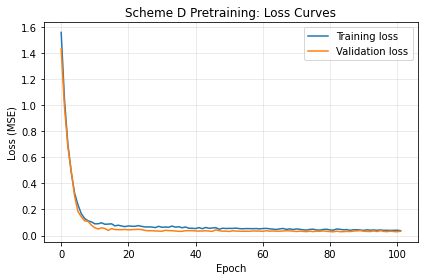

In [12]:
# ============================================================
# 11. Plot the pretraining loss curves
# ============================================================
plt.figure(figsize=(6, 4))

plt.plot(
    pretrain_train_losses,
    label="Training loss"
)

plt.plot(
    pretrain_val_losses,
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Scheme D Pretraining: Loss Curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [13]:
# ============================================================
# 12. Save the pretraining predictions
# ============================================================
os.makedirs(
    "results",
    exist_ok=True
)

pretrain_train_df = pd.DataFrame(
    {
        "Actual_Overpotential": (
            y_pretrain_train_true
        ),
        "Predicted_Overpotential": (
            y_pretrain_train_pred
        ),
        "Absolute_Error": np.abs(
            y_pretrain_train_true
            - y_pretrain_train_pred
        )
    }
)

pretrain_val_df = pd.DataFrame(
    {
        "Actual_Overpotential": (
            y_pretrain_val_true
        ),
        "Predicted_Overpotential": (
            y_pretrain_val_pred
        ),
        "Absolute_Error": np.abs(
            y_pretrain_val_true
            - y_pretrain_val_pred
        )
    }
)

pretrain_train_path = (
    "results/schemeD_pretrain_train_predictions.csv"
)

pretrain_val_path = (
    "results/schemeD_pretrain_val_predictions.csv"
)

pretrain_train_df.to_csv(
    pretrain_train_path,
    index=False
)

pretrain_val_df.to_csv(
    pretrain_val_path,
    index=False
)

print(
    "Scheme D pretraining predictions "
    f"for the training set saved to: {pretrain_train_path}"
)

print(
    "Scheme D pretraining predictions "
    f"for the validation set saved to: {pretrain_val_path}"
)


Scheme D pretraining predictions for the training set saved to: results/schemeD_pretrain_train_predictions.csv
Scheme D pretraining predictions for the validation set saved to: results/schemeD_pretrain_val_predictions.csv


In [14]:
# ============================================================
# 13. Save the pretrained model and scaler
# ============================================================
os.makedirs(
    "model",
    exist_ok=True
)

pretrained_model_path = (
    "model/mlp_schemeD_pretrained.pth"
)

pretrained_scaler_path = (
    "model/scaler_schemeD_pretrained.pkl"
)

torch.save(
    model_D_pretrained.state_dict(),
    pretrained_model_path
)

joblib.dump(
    scaler_pretrain,
    pretrained_scaler_path
)

print(
    "Scheme D pretrained model saved to:",
    pretrained_model_path
)

print(
    "Scheme D pretraining scaler saved to:",
    pretrained_scaler_path
)

Scheme D pretrained model saved to: model/mlp_schemeD_pretrained.pth
Scheme D pretraining scaler saved to: model/scaler_schemeD_pretrained.pkl
